In [ ]:
# Импрот библиотек
import pandas as pd
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport

In [10]:
# Превращаем файл в датафрейм
df = pd.read_csv('Warehouse_and_Retail_Sales.csv')

In [19]:
df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [20]:
# Запускаем анализ данных по pandas-profiling
profile = ProfileReport(df, title="Profiling Report")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:05<00:00,  1.72it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## Выводы
1. Самая сильная связь: RETAIL SALES и RETAIL TRANSFERS (0.823)
Это очень сильная прямая корреляция.
Что это значит: Розничные продажи практически неразрывно связаны с перемещением товаров. Чем больше товара перемещается со склада в розничные точки, тем выше продажи.
Для регрессии: Это идеальный кандидат. Можно построить модель, которая будет предсказывать розничные продажи на основе объема перемещений.
2. Слабая связь: RETAIL SALES и WAREHOUSE SALES (0.003)
А вот это инсайт! Корреляция почти нулевая.
Что это значит: Оптовые продажи (со склада) живут своей жизнью и никак не коррелируют с розничными продажами за тот же период. Это логично: оптовики могут закупаться впрок, а розница продает по чуть-чуть конечному клиенту.
Вывод: Использовать оптовые продажи как фактор для предсказания розничных в лоб — плохая идея.
3. Техническая корреляция: YEAR и MONTH (0.512)
Она умеренная, но это «шум». Она возникла просто потому, что данные в датасете идут последовательно по времени. В анализе её обычно игнорируют.


In [21]:
df.isnull().sum()

YEAR                  0
MONTH                 0
SUPPLIER            167
ITEM CODE             0
ITEM DESCRIPTION      0
ITEM TYPE             1
RETAIL SALES          3
RETAIL TRANSFERS      0
WAREHOUSE SALES       0
dtype: int64

In [22]:
# Удаляем строки, где пустые значения в указанных столбцах
df = df.dropna(subset=['SUPPLIER', 'ITEM TYPE', 'RETAIL SALES'])

# Проверяем, что теперь везде 0
print(df.isnull().sum())

YEAR                0
MONTH               0
SUPPLIER            0
ITEM CODE           0
ITEM DESCRIPTION    0
ITEM TYPE           0
RETAIL SALES        0
RETAIL TRANSFERS    0
WAREHOUSE SALES     0
dtype: int64


In [58]:
# Выбрали бренд, создаем датафрейм с нужными столбцами
# df_regr = df_total[['месяц', 'год', 'Брэнд', 'Объем_дал']]
# df_regr

,месяц,год,Брэнд,Объем_дал
0,1,2022,Брэнд_7,5.52
1,1,2022,Брэнд_8,5.52
2,1,2022,Брэнд_8,9.20
3,1,2022,Брэнд_7,4.60
4,1,2022,Брэнд_8,5.52
...,...,...,...,...
122114,8,2023,Брэнд_1,115.00
122115,8,2023,Брэнд_1,165.60
122116,8,2023,Брэнд_1,5.52
122117,8,2023,Брэнд_2,4.60


In [24]:
# 1. Подготовка категорий (One-Hot Encoding для ITEM TYPE)
# Мы превращаем Wine, Beer и т.д. в отдельные колонки 0 и 1
df_ohe = pd.get_dummies(df, columns=['ITEM TYPE'], drop_first=True)
df_ohe.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES,ITEM TYPE_DUNNAGE,ITEM TYPE_KEGS,ITEM TYPE_LIQUOR,ITEM TYPE_NON-ALCOHOL,ITEM TYPE_REF,ITEM TYPE_STR_SUPPLIES,ITEM TYPE_WINE
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,0.00,0.0,2.0,False,False,False,False,False,False,True
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,0.00,1.0,4.0,False,False,False,False,False,False,True
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,0.00,0.0,1.0,False,False,False,False,False,False,False
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,0.00,0.0,1.0,False,False,False,False,False,False,True
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,0.82,0.0,0.0,False,False,False,False,False,False,True


In [26]:
import statsmodels.api as sm
# 2. Формируем список факторов (X)
# Берем год, месяц и все новые колонки, которые создались из ITEM TYPE
features = ['YEAR', 'MONTH'] + [col for col in df_ohe.columns if col.startswith('ITEM TYPE_')]
X = df_ohe[features].astype(float) # Приводим к числу для корректности
y = df_ohe['RETAIL SALES']

# 3. Добавляем константу (интерсепт) — это обязательно для OLS
X = sm.add_constant(X)

# 4. Обучаем модель
model = sm.OLS(y, X).fit()

# 5. Выводим отчет
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           RETAIL SALES   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     744.9
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:03:28   Log-Likelihood:            -1.4827e+06
No. Observations:              307477   AIC:                         2.965e+06
Df Residuals:                  307467   BIC:                         2.966e+06
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   -435

### Выводы по базовой регрессионной модели:
Низкая объясняющая способность (R2 = 2,1%): Факторы времени (год, месяц) и категории товара практически не определяют объем розничных продаж. Это указывает на то, что спрос зависит от внешних драйверов: маркетинга, цен или наличия товара на полках.

Статистическая значимость: Несмотря на слабый общий эффект, время (Year, Month) и категории (Wine, Liquor) имеют подтвержденное влияние (P-value <0,05). Продажи имеют слабую тенденцию к росту с течением времени и к концу календарного года.

Сравнение категорий: Продажи вина (Wine) в среднем на 9.5 единиц ниже, чем у базовой категории (пива), при прочих равных условиях.

Отсутствие автокорреляции: Значение теста Дурбина-Уотсона (1.86) близко к 2, что говорит о независимости ошибок — данные не имеют скрытых системных сдвигов во времени.

In [28]:
# Переоубчим модель, добавив перемещения
# Добавляем RETAIL TRANSFERS в список признаков
features_new = ['YEAR', 'MONTH', 'RETAIL TRANSFERS'] + [col for col in df_ohe.columns if col.startswith('ITEM TYPE_')]

X_new = df_ohe[features_new].astype(float)
y = df_ohe['RETAIL SALES']

# Добавляем константу и обучаем
X_new = sm.add_constant(X_new)
model_new = sm.OLS(y, X_new).fit()

print(model_new.summary())

                            OLS Regression Results                            
Dep. Variable:           RETAIL SALES   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                 7.379e+05
Date:                Wed, 04 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:08:33   Log-Likelihood:            -9.9116e+05
No. Observations:              307477   AIC:                         1.982e+06
Df Residuals:                  307466   BIC:                         1.982e+06
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -55

## Выводы по регрессионному анализу (Финал)
Найден ключевой драйвер: Включение логистического фактора (RETAIL TRANSFERS) подняло точность модели с 2% до 96% (R2=0,96). Это доказывает, что розничные продажи в этой сети почти полностью зависят от объемов текущих поставок со склада.

Эффективность цепочки поставок: Коэффициент 0.98 у перемещений означает, что каждая единица товара, отправленная в магазин, конвертируется в продажу практически «один к одному». Это признак высокой оборачиваемости и отсутствия затоваривания полок.

Вторичность времени и категорий: После учета поставок влияние года, месяца и типа товара стало минимальным. Это значит, что «сезонность» или «популярность вина» уже заложены в объемы поставок менеджерами склада.

Аномалии в категориях: Отрицательный коэффициент у STR_SUPPLIES подтверждает, что расходные материалы для магазинов перемещаются со склада в больших объемах, но не генерируют выручку (так как не являются товаром для продажи).


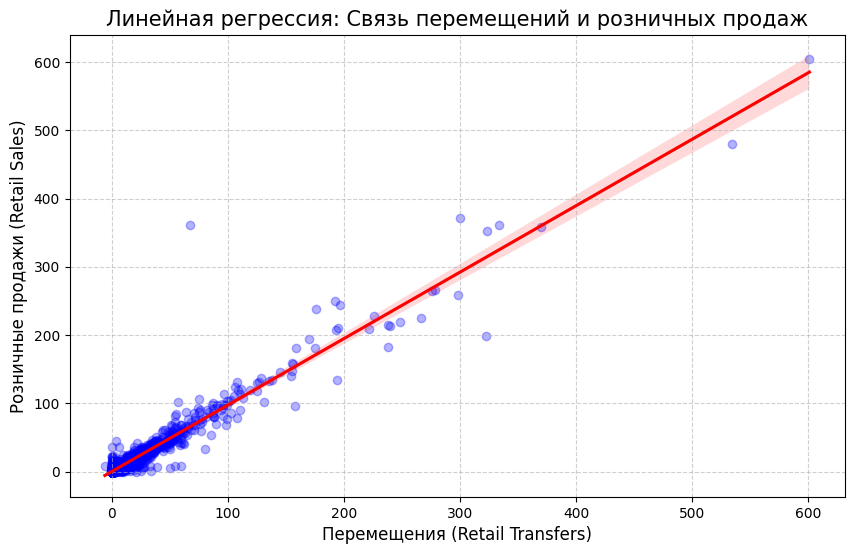

In [32]:
# Построим график для визуализации
%matplotlib inline
import seaborn as sns
plt.figure(figsize=(10, 6))
# Выбираем небольшую выборку для графика, чтобы он не "завис" на 300к строк
df_sample = df.sample(5000, random_state=42)

sns.regplot(x='RETAIL TRANSFERS', y='RETAIL SALES', data=df_sample, 
            scatter_kws={'alpha':0.3, 'color':'blue'}, 
            line_kws={'color':'red'})

plt.title('Линейная регрессия: Связь перемещений и розничных продаж', fontsize=15)
plt.xlabel('Перемещения (Retail Transfers)', fontsize=12)
plt.ylabel('Розничные продажи (Retail Sales)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

### Факторный анализ (ABC-анализ)

In [36]:
# Группируем продажи по поставщикам
supplier_sales = df.groupby('SUPPLIER')['RETAIL SALES'].sum().sort_values(ascending=False).reset_index()

# Считаем накопленную долю
supplier_sales['cum_share'] = supplier_sales['RETAIL SALES'].cumsum() / supplier_sales['RETAIL SALES'].sum()

# Присваиваем категории ABC
def abc_segment(share):
    if share <= 0.8: return 'A (VIP)'
    elif share <= 0.95: return 'B (Medium)'
    else: return 'C (Small)'

supplier_sales['Category'] = supplier_sales['cum_share'].apply(abc_segment)

# Смотрим результат: сколько поставщиков в категории А
print(supplier_sales['Category'].value_counts())
print("\nТоп-5 поставщиков (Категория А):")
print(supplier_sales.head(5))

Category
C (Small)     321
B (Medium)     46
A (VIP)        29
Name: count, dtype: int64

Топ-5 поставщиков (Категория А):
                   SUPPLIER  RETAIL SALES  cum_share Category
0        E & J GALLO WINERY     166170.53   0.077164  A (VIP)
1  DIAGEO NORTH AMERICA INC     145343.20   0.144657  A (VIP)
2      CONSTELLATION BRANDS     131664.79   0.205798  A (VIP)
3        ANHEUSER BUSCH INC     109960.82   0.256861  A (VIP)
4        JIM BEAM BRANDS CO      96164.04   0.301516  A (VIP)


Категория А (VIP): Всего 29 компаний (это лишь 7% от общего числа поставщиков) приносят 80% всей выручки.
Категория С (Small): Огромный «хвост» из 321 поставщика (81% базы) генерирует лишь последние 5% продаж.

Бизнес демонстрирует критическую зависимость от узкого круга лиц: потеря даже одного поставщика из топ-10 (например, E & J Gallo Winery или Diageo) может обрушить продажи на 7-8%. С другой стороны, работа с категорией С требует огромных операционных ресурсов (логистика, документы, закупки) при минимальном финансовом выхлопе.